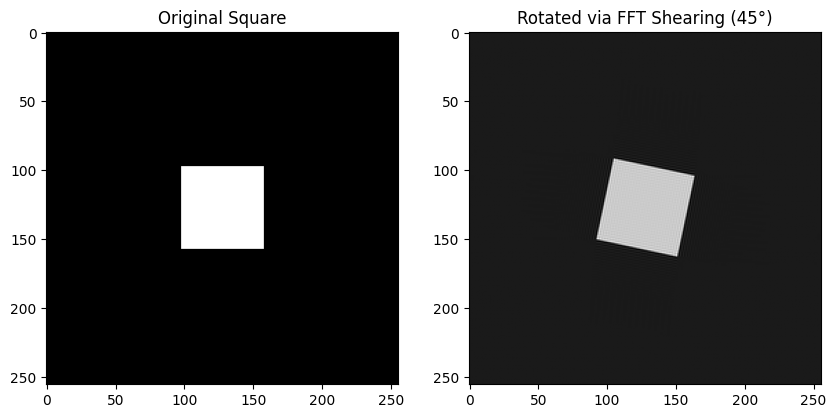

In [30]:
import torch
import torch.fft as fft
import matplotlib.pyplot as plt
import numpy as np


def fft_shear(image, shift_amounts, axis):
    """
    Applies a shear to a 2D tensor using the Fourier Shift Theorem.
    """
    rows, cols = image.shape
    # Get frequencies
    freqs = fft.fftfreq(rows if axis == 0 else cols).to(image.device)

    # Reshape freqs to broadcast against the image
    if axis == 0:  # Vertical shear
        freqs = freqs.view(-1, 1)
        shift_amounts = shift_amounts.view(1, -1)
    else:  # Horizontal shear
        freqs = freqs.view(1, -1)
        shift_amounts = shift_amounts.view(-1, 1)

    # Compute phase shift: exp(-2j * pi * freq * shift)
    phase_shift = torch.exp(-2j * np.pi * freqs * shift_amounts)

    # Apply FFT, multiply by phase shift, and IFFT
    image_fft = fft.fft(image, dim=axis)
    shifted_fft = image_fft * phase_shift
    return fft.ifft(shifted_fft, dim=axis).real


def rotate_fft(image, theta_deg):
    theta = np.radians(theta_deg)
    rows, cols = image.shape

    # Calculate shear factors
    a = -np.tan(theta / 2)
    b = np.sin(theta)

    # Create coordinate ramps for shifts
    # We shift each row/column by a factor proportional to its distance from center
    x_indices = torch.linspace(-cols / 2, cols / 2, cols)
    y_indices = torch.linspace(-rows / 2, rows / 2, rows)

    # 1. First Horizontal Shear
    image = fft_shear(image, a * y_indices, axis=1)

    # 2. Vertical Shear
    image = fft_shear(image, b * x_indices, axis=0)

    # 3. Second Horizontal Shear
    image = fft_shear(image, a * y_indices, axis=1)

    return image


# --- Execution ---
size = 256
square_size = 60
img = torch.zeros((size, size))
# Create a square in the center
img[
    size // 2 - square_size // 2 : size // 2 + square_size // 2,
    size // 2 - square_size // 2 : size // 2 + square_size // 2,
] = 1.0

rotated_img = rotate_fft(img, 12)  # Rotate 45 degrees

# Visualization
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Square")
plt.imshow(img, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Rotated via FFT Shearing (45°)")
plt.imshow(rotated_img, cmap="gray")
plt.show()

3D

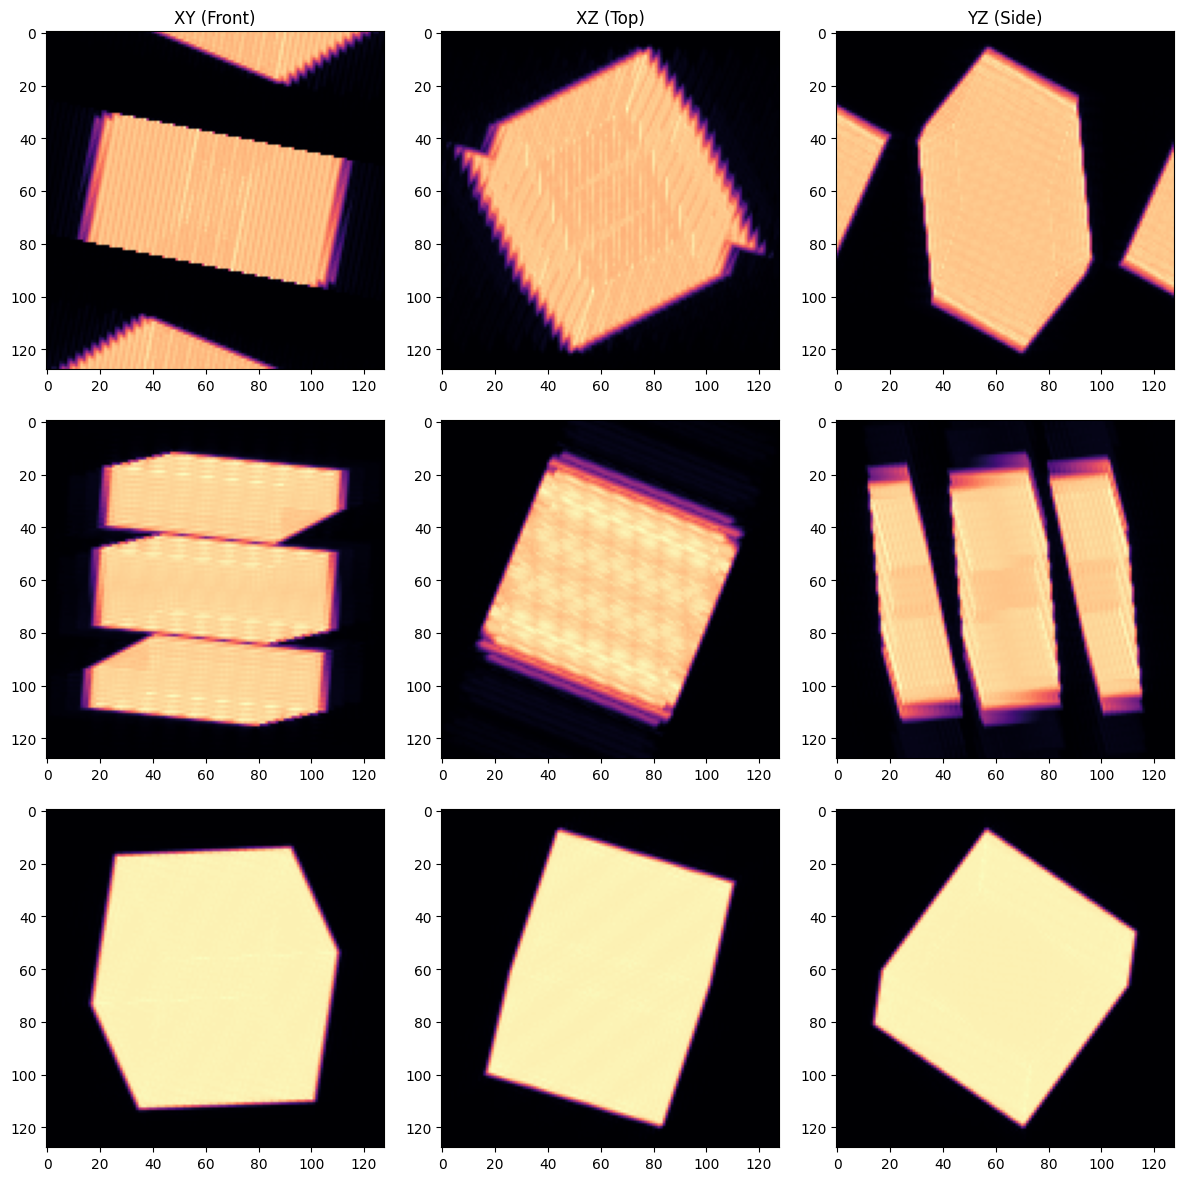

In [79]:
import torch
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R


def create_custom_cube(n, size_x, size_y, size_z):
    """Creates a 3D block with custom dimensions in a grid of size n."""
    vol = torch.zeros((n, n, n))
    # Calculate bounds to center the cube
    x0, x1 = n // 2 - size_x // 2, n // 2 + size_x // 2
    y0, y1 = n // 2 - size_y // 2, n // 2 + size_y // 2
    z0, z1 = n // 2 - size_z // 2, n // 2 + size_z // 2
    vol[z0:z1, y0:y1, x0:x1] = 1.0
    return vol


def fast_shear_3d_clean(v, shift, ctrl_axis, move_axis):
    """Vectorized FFT shear with a low-pass filter to prevent aliasing."""
    sz_ctrl, sz_move = v.shape[ctrl_axis], v.shape[move_axis]
    device = v.device

    freqs = fft.fftfreq(sz_move, device=device)
    ramp = torch.linspace(-(sz_ctrl - 1) / 2, (sz_ctrl - 1) / 2, sz_ctrl, device=device)

    f_shape = [1, 1, 1]
    f_shape[move_axis] = -1
    r_shape = [1, 1, 1]
    r_shape[ctrl_axis] = -1

    # Calculate Phase Shift
    phase = torch.exp(-2j * np.pi * freqs.view(f_shape) * (shift * ramp.view(r_shape)))

    # Anti-Aliasing Filter (Gaussian)
    sigma = 0.48
    filter_lp = torch.exp(-0.5 * (freqs.view(f_shape) / sigma) ** 2)

    v_fft = fft.fft(v, dim=move_axis)
    return fft.ifft(v_fft * phase * filter_lp, dim=move_axis).real


@torch.no_grad()
def rotate_3d_rigid(vol, q):
    N = vol.shape[0]
    # Padding to sqrt(3) * N is safe for all orientations
    pad_size = int(N * 0.5)
    vol_padded = torch.nn.functional.pad(vol, [pad_size] * 6)

    # Use SciPy to extract the exact ZYZ angles needed for our 3-pass logic
    # SciPy expects [x, y, z, w]
    rot_obj = R.from_quat(q.cpu().numpy())
    alpha, beta, gamma = rot_obj.as_euler("ZYZ", degrees=False)

    def rotate_slices(v, angle, d1, d2):
        if abs(angle) < 1e-6:
            return v
        a, b = -torch.tan(torch.tensor(angle / 2)), torch.sin(torch.tensor(angle))
        v = fast_shear_3d_clean(v, a, d1, d2)
        v = fast_shear_3d_clean(v, b, d2, d1)
        v = fast_shear_3d_clean(v, a, d1, d2)
        return v

    # Z-Y-Z Rotation Sequence (9 shears total)
    vol_padded = rotate_slices(vol_padded, alpha, 1, 2)  # Around Z
    vol_padded = vol_padded.permute(1, 0, 2)  # Swap to rotate around Y
    vol_padded = rotate_slices(vol_padded, beta, 1, 2)
    vol_padded = vol_padded.permute(1, 0, 2)  # Swap back
    vol_padded = rotate_slices(vol_padded, gamma, 1, 2)  # Around Z

    s = pad_size
    return vol_padded[s : s + N, s : s + N, s : s + N]


# --- CONFIGURATION ---
GRID_SIZE = 128
# Adjust these values to change the size of the cube!
CUBE_X = 70
CUBE_Y = 70
CUBE_Z = 70

# Initialize
cube = create_custom_cube(GRID_SIZE, CUBE_X, CUBE_Y, CUBE_Z)

# Plotting 3 random examples with the custom size
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    q_rand = torch.randn(4)
    q_rand /= q_rand.norm()
    res = rotate_3d_rigid(cube.clone(), q_rand)

    axes[i, 0].imshow(res.max(0)[0], cmap="magma")
    axes[i, 1].imshow(res.max(1)[0], cmap="magma")
    axes[i, 2].imshow(res.max(2)[0], cmap="magma")

    if i == 0:
        axes[i, 0].set_title("XY (Front)")
        axes[i, 1].set_title("XZ (Top)")
        axes[i, 2].set_title("YZ (Side)")

plt.tight_layout()
plt.show()

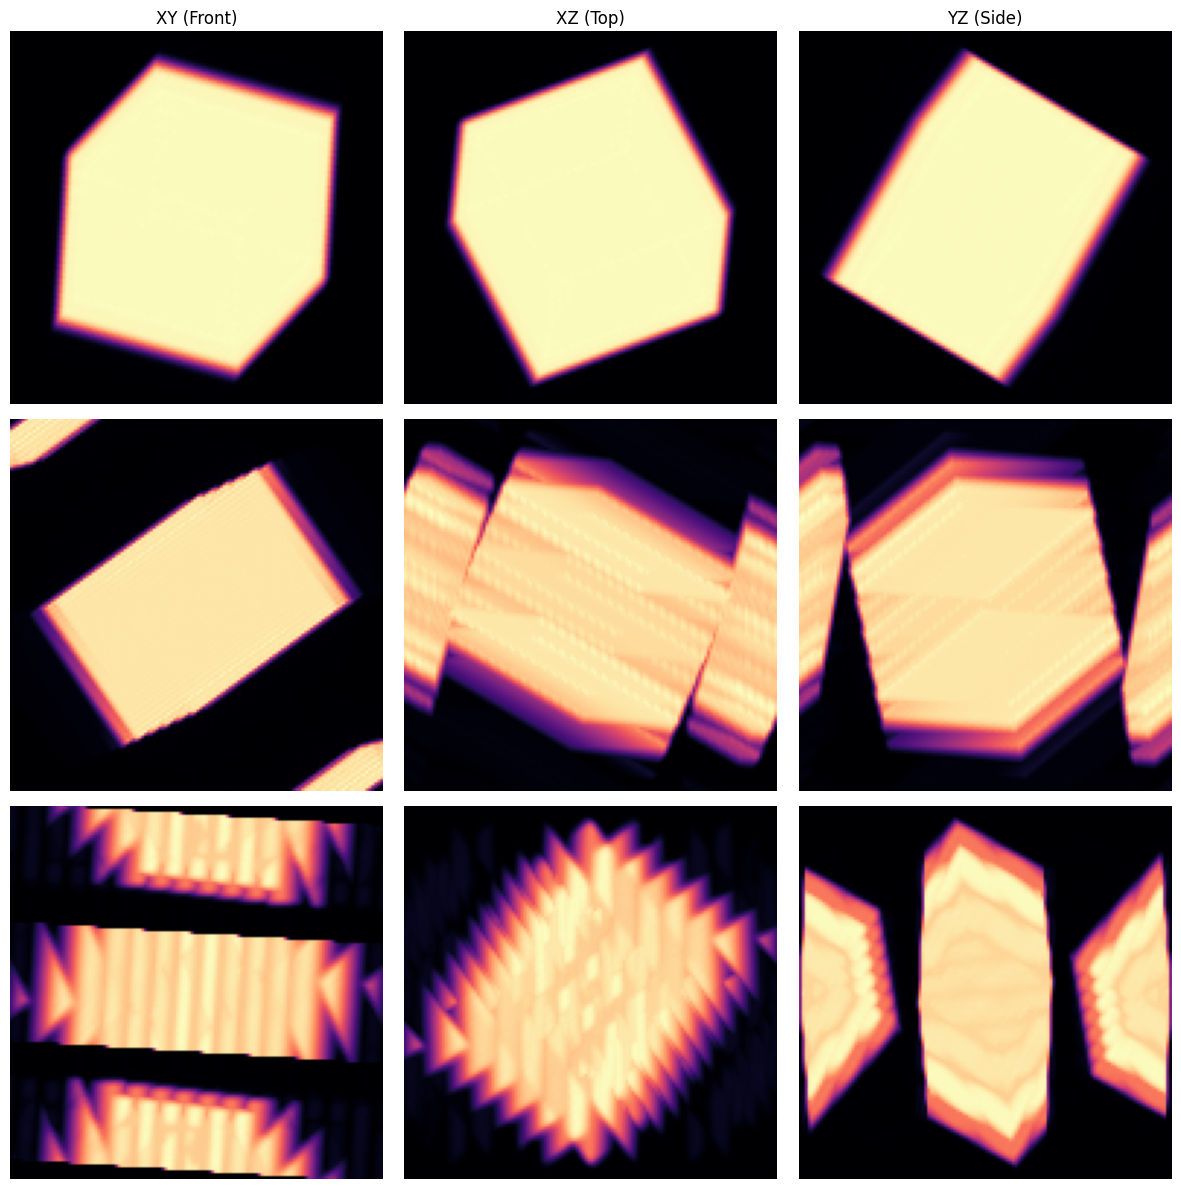

In [86]:
import torch
import matplotlib.pyplot as plt


# -------------------------
# 1️⃣ Cube / Block Creation
# -------------------------
def create_block(n, size, device="cpu", dtype=torch.float32):
    """
    Creates a centered 3D block of ones in a volume of zeros.
    size: tuple (z, y, x)
    """
    vol = torch.zeros((n, n, n), device=device, dtype=dtype)
    z0, y0, x0 = [(n - s) // 2 for s in size]
    z1, y1, x1 = z0 + size[0], y0 + size[1], x0 + size[2]
    vol[z0:z1, y0:y1, x0:x1] = 1.0
    return vol


# -------------------------
# 2️⃣ Edge Windowing
# -------------------------
def apply_window_3d(v, edge_fraction=0.05):
    """Applies a 3D Hann window at edges to reduce FFT aliasing."""
    n = v.shape[0]
    wlen = max(2, int(n * edge_fraction * 2))
    hann = torch.hann_window(wlen, periodic=False, device=v.device)
    w_full = torch.ones(n, device=v.device)
    w_full[: wlen // 2] = hann[: wlen // 2]
    w_full[-wlen // 2 :] = hann[-wlen // 2 :]

    v = v * w_full.view(-1, 1, 1)
    v = v * w_full.view(1, -1, 1)
    v = v * w_full.view(1, 1, -1)
    return v


# -------------------------
# 3️⃣ FFT Shear (1D)
# -------------------------
def fast_shear_1d(v, shift, ctrl_axis, move_axis, sigma=None):
    """
    Performs FFT-based shear along move_axis.
    shift: shear magnitude
    sigma: Gaussian low-pass filter width (smaller = stronger anti-alias)
    """
    sz_ctrl, sz_move = v.shape[ctrl_axis], v.shape[move_axis]
    freqs = fft.fftfreq(sz_move, device=v.device)
    ramp = torch.linspace(
        -(sz_ctrl - 1) / 2, (sz_ctrl - 1) / 2, sz_ctrl, device=v.device
    )

    f_shape = [1] * v.ndim
    f_shape[move_axis] = sz_move
    r_shape = [1] * v.ndim
    r_shape[ctrl_axis] = sz_ctrl

    phase = torch.exp(-2j * np.pi * freqs.view(f_shape) * (shift * ramp.view(r_shape)))

    if sigma is None:
        sigma = max(0.2, 0.48 - 0.1 * abs(shift))  # adaptive LP filter
    filter_lp = torch.exp(-0.5 * (freqs.view(f_shape) / sigma) ** 2)

    v_fft = fft.fft(v, dim=move_axis)
    return fft.ifft(v_fft * phase * filter_lp, dim=move_axis).real


# -------------------------
# 4️⃣ Rigid Rotation
# -------------------------
@torch.no_grad()
def rotate_3d_rigid(vol, q, CUBE_SIZE):
    """
    Rotates a 3D volume using FFT-based 3-pass shears (Z-Y-Z sequence).
    vol: torch tensor [N,N,N]
    q: quaternion [x, y, z, w]
    """
    N = vol.shape[0]
    # Pad volume to avoid clipping after rotation
    # pad_size = int(np.ceil(N * np.sqrt(3)/2))
    pad_size = int(np.ceil(N + max(CUBE_SIZE) * 2))  # huge safe padding
    vol_padded = torch.nn.functional.pad(vol, [pad_size] * 6)

    # Apply edge windowing to reduce aliasing
    vol_padded = apply_window_3d(vol_padded, edge_fraction=0.05)

    # Convert quaternion -> Euler ZYZ
    rot_obj = R.from_quat(q.cpu().numpy())
    alpha, beta, gamma = rot_obj.as_euler("ZYZ", degrees=False)

    def rotate_slices(v, angle, d1, d2):
        if abs(angle) < 1e-6:
            return v
        a = -torch.tan(torch.tensor(angle / 2, device=v.device))
        b = torch.sin(torch.tensor(angle, device=v.device))
        v = fast_shear_1d(v, a, d1, d2)
        v = fast_shear_1d(v, b, d2, d1)
        v = fast_shear_1d(v, a, d1, d2)
        return v

    # Z-Y-Z rotation sequence
    vol_padded = rotate_slices(vol_padded, alpha, 1, 2)  # Rotate around Z
    vol_padded = torch.movedim(vol_padded, 0, 1)  # Swap axes for Y
    vol_padded = rotate_slices(vol_padded, beta, 1, 2)  # Rotate around Y
    vol_padded = torch.movedim(vol_padded, 1, 0)  # Swap back
    vol_padded = rotate_slices(vol_padded, gamma, 1, 2)  # Rotate around Z

    s = pad_size
    return vol_padded[s : s + N, s : s + N, s : s + N]


# -------------------------
# 5️⃣ Visualization
# -------------------------
def plot_rotated_cubes(cube, n_examples=3, CUBE_SIZE=10):
    fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))
    for i in range(n_examples):
        q_rand = torch.randn(4)
        q_rand /= q_rand.norm()
        res = rotate_3d_rigid(cube.clone(), q_rand, CUBE_SIZE)

        axes[i, 0].imshow(res.max(0)[0].cpu(), cmap="magma")
        axes[i, 0].axis("off")
        axes[i, 1].imshow(res.max(1)[0].cpu(), cmap="magma")
        axes[i, 1].axis("off")
        axes[i, 2].imshow(res.max(2)[0].cpu(), cmap="magma")
        axes[i, 2].axis("off")

        if i == 0:
            axes[i, 0].set_title("XY (Front)")
            axes[i, 1].set_title("XZ (Top)")
            axes[i, 2].set_title("YZ (Side)")

    plt.tight_layout()
    plt.show()


# -------------------------
# 6️⃣ CONFIGURATION & RUN
# -------------------------
GRID_SIZE = 128
CUBE_SIZE = (70, 70, 70)

device = "cuda" if torch.cuda.is_available() else "cpu"
cube = create_block(GRID_SIZE, CUBE_SIZE, device=device)

plot_rotated_cubes(cube, n_examples=3, CUBE_SIZE=CUBE_SIZE)

## Without fft

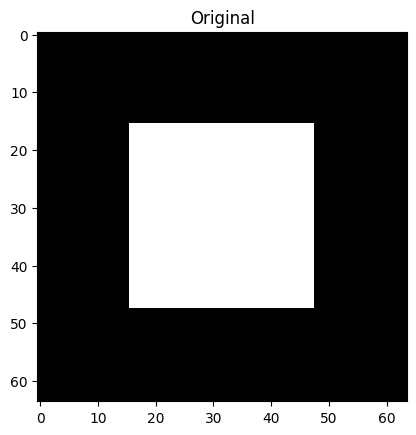

In [2]:
import torch
import matplotlib.pyplot as plt
import math

# Create a simple square image
D = 64
img = torch.zeros(D, D)
img[D // 4 : 3 * D // 4, D // 4 : 3 * D // 4] = 1.0

plt.imshow(img, cmap="gray")
plt.title("Original")
plt.show()

In [3]:
import torch.nn.functional as F


def shear_x_real(img, s):
    """
    Shear along x: x -> x + s*y
    Uses simple bilinear interpolation via grid_sample
    """
    D = img.shape[0]
    device = img.device

    # Normalize coordinates to [-1, 1] for grid_sample
    y, x = torch.meshgrid(
        torch.arange(D, device=device), torch.arange(D, device=device)
    )
    x = x.float()
    y = y.float()
    x_center = D // 2
    y_center = D // 2

    # shift origin to center
    x_shifted = x - x_center + s * (y - y_center)
    y_shifted = y - y_center

    # normalize to [-1, 1]
    x_norm = 2 * x_shifted / (D - 1)
    y_norm = 2 * y_shifted / (D - 1)

    grid = torch.stack((x_norm, y_norm), dim=-1).unsqueeze(0)  # (1, D, D, 2)
    img_in = img.unsqueeze(0).unsqueeze(0)  # (1, 1, D, D)

    out = F.grid_sample(
        img_in, grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out[0, 0]

In [4]:
def shear_y_real(img, s):
    """
    Shear along y: y -> y + s*x
    """
    D = img.shape[0]
    device = img.device

    y, x = torch.meshgrid(
        torch.arange(D, device=device), torch.arange(D, device=device)
    )
    x = x.float()
    y = y.float()
    x_center = D // 2
    y_center = D // 2

    x_shifted = x - x_center
    y_shifted = y - y_center + s * (x - x_center)

    x_norm = 2 * x_shifted / (D - 1)
    y_norm = 2 * y_shifted / (D - 1)

    grid = torch.stack((x_norm, y_norm), dim=-1).unsqueeze(0)
    img_in = img.unsqueeze(0).unsqueeze(0)

    out = F.grid_sample(
        img_in, grid, mode="bilinear", padding_mode="zeros", align_corners=True
    )
    return out[0, 0]

In [5]:
def rotate_2d_real(img, theta):
    a = -math.tan(theta / 2)
    b = math.sin(theta)

    out = shear_x_real(img, a)
    out = shear_y_real(out, b)
    out = shear_x_real(out, a)
    return out

/mnt/cbis/home/e0788253/czii/cryosim/.venv/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


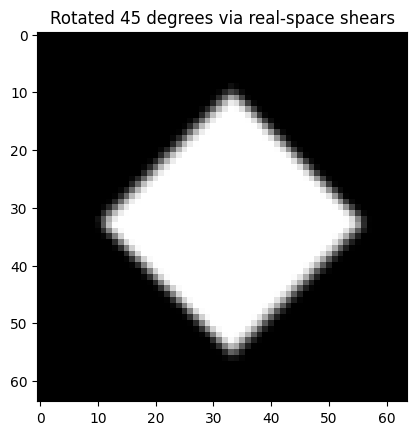

In [6]:
theta = math.pi / 4  # 45 degrees
rotated = rotate_2d_real(img, theta)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated 45 degrees via real-space shears")
plt.show()

## Gemini-paper

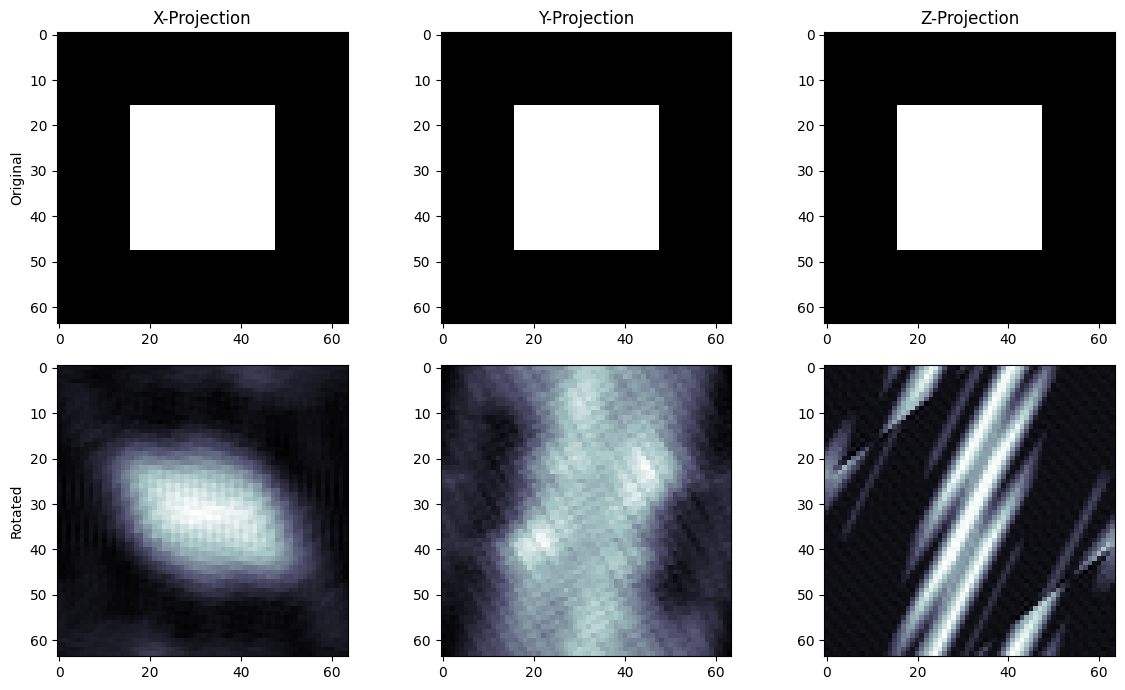

In [119]:
import torch
import torch.fft
import matplotlib.pyplot as plt


def get_shear_coefficients(q):
    """Calculates coefficients a-h for SySzSxSy (Eq. 5b)[cite: 143, 145]."""
    X, Y, Z, W = q
    denom1 = Y * Z - X * W
    denom2 = X * Y - Z * W

    if abs(denom1) < 1e-9 or abs(denom2) < 1e-9:
        return {k: 0.0 for k in "abcdefgh"}

    # Formulas from [cite: 145]
    a = (X**2 + Y**2) / denom1
    b = (Y**2 - Z**2) / denom2 - 2 * (Y * Z * (X**2 + Y**2)) / (denom2 * denom1)
    c = 2 * (Y * Z) / denom2
    d = 2 * (X * W - Y * Z)
    e = 2 * (X * Y - Z * W)
    f = -2 * (X * Y) / denom1
    g = (X**2 - Y**2) / denom1 + 2 * (X * Y * (Y**2 + Z**2)) / (denom2 * denom1)
    h = (-1 + X**2 + W**2) / denom2
    return {"a": a, "b": b, "c": c, "d": d, "e": e, "f": f, "g": g, "h": h}


def apply_shear(volume, axis, coeffs):
    """
    Applies a shearing transformation Sj(a, b, delta) using Fourier methods[cite: 491].

    Args:
        volume (torch.Tensor): 3D volume to be sheared (shape: [Nx, Ny, Nz]).
        axis (int): The axis being sheared (0 for X, 1 for Y, 2 for Z).
        coeffs (tuple): (a, b, delta) coefficients from Eq. (5b) [cite: 588].
                        Note: delta is often 0 for pure rotations[cite: 488].
    """
    device = volume.device
    dims = volume.shape
    Nx, Ny, Nz = dims

    # 1. Identify non-shearing axes for the 2D FFT [cite: 491, 492]
    # To shear X, we FFT in Y and Z. To shear Y, we FFT in X and Z, etc.
    fft_axes = [i for i in range(3) if i != axis]

    # 2. Perform FFT in the non-shearing directions [cite: 492]
    # We use fftshift to center the zero-frequency component[cite: 189].
    v_fft = torch.fft.fftn(volume, dim=fft_axes)
    v_fft = torch.fft.fftshift(v_fft, dim=fft_axes)

    # 3. Setup grid indices centered from -N/2 to (N/2)-1 [cite: 496]
    # n_shear: coordinate grid for the axis being sheared.
    # n_other0, n_other1: frequency grids for the perpendicular axes.
    n_shear = torch.arange(-dims[axis] // 2, dims[axis] // 2, device=device)
    n_other0 = torch.arange(
        -dims[fft_axes[0]] // 2, dims[fft_axes[0]] // 2, device=device
    )
    n_other1 = torch.arange(
        -dims[fft_axes[1]] // 2, dims[fft_axes[1]] // 2, device=device
    )

    a, b, delta = coeffs  # delta is the translation component [cite: 487]

    # 4. Calculate the phase shift [cite: 493]
    # Equation: 2*pi * (delta + (a*ny/Ny) + (b*nz/Nz)) * nx
    # We reshape components to ensure proper 3D broadcasting.
    if axis == 0:  # Sx: Shift X based on Y and Z
        # n_shear: (Nx, 1, 1), n_other0: (1, Ny, 1), n_other1: (1, 1, Nz)
        shift = (
            delta
            + (a * n_other0.reshape(1, -1, 1) / Ny)
            + (b * n_other1.reshape(1, 1, -1) / Nz)
        ) * n_shear.reshape(-1, 1, 1)
    elif axis == 1:  # Sy: Shift Y based on X and Z
        # n_other1: (Nx, 1, 1), n_shear: (1, Ny, 1), n_other0: (1, 1, Nz)
        shift = (
            delta
            + (a * n_other0.reshape(1, 1, -1) / Nz)
            + (b * n_other1.reshape(-1, 1, 1) / Nx)
        ) * n_shear.reshape(1, -1, 1)
    else:  # Sz: Shift Z based on X and Y
        # n_other0: (Nx, 1, 1), n_other1: (1, Ny, 1), n_shear: (1, 1, Nz)
        shift = (
            delta
            + (a * n_other0.reshape(-1, 1, 1) / Nx)
            + (b * n_other1.reshape(1, -1, 1) / Ny)
        ) * n_shear.reshape(1, 1, -1)

    # 5. Handle the Nyquist frequency limit for real data [cite: 500, 502]
    # Rule: The -N/2 sample (index 0 after fftshift) must not be phase shifted
    # if the input data is purely real to avoid information loss[cite: 509, 513].
    if not torch.is_complex(volume):
        # Create a mask to zero out phase for Nyquist bins
        mask = torch.ones_like(shift)
        # Assuming fft_axes[0] is at index 0 and fft_axes[1] at index 0 after shift
        if axis == 0:  # Y and Z are FFT axes
            mask[:, 0, :] = 0
            mask[:, :, 0] = 0
        elif axis == 1:  # X and Z are FFT axes
            mask[0, :, :] = 0
            mask[:, :, 0] = 0
        else:  # X and Y are FFT axes
            mask[0, :, :] = 0
            mask[:, 0, :] = 0
        shift = shift * mask

    # 6. Apply phase shift and perform inverse FFT [cite: 493]
    v_fft *= torch.exp(-2j * np.pi * shift)
    v_fft = torch.fft.ifftshift(v_fft, dim=fft_axes)
    return torch.fft.ifftn(v_fft, dim=fft_axes).real


def rotate_3d_fourier(volume, q):
    """
    Forward decomposition sequence: Sy -> Sz -> Sx -> Sy.
    Each shear now passes (coeff_a, coeff_b, translation_delta).
    """
    s = get_shear_coefficients(q)

    # Pass 0.0 as the third argument (delta) for pure rotation [cite: 77]
    vol = apply_shear(volume, 1, (s["g"], s["h"], 0.0))
    vol = apply_shear(vol, 2, (s["c"], s["d"], 0.0))
    vol = apply_shear(vol, 0, (s["e"], s["f"], 0.0))
    vol = apply_shear(vol, 1, (s["a"], s["b"], 0.0))

    return vol


# --- Demonstration ---
size = 64
cube = torch.zeros((size, size, size))
cube[
    size // 4 : 3 * size // 4, size // 4 : 3 * size // 4, size // 4 : 3 * size // 4
] = 1.0

# 30-degree rotation around an arbitrary axis
theta = np.deg2rad(30)
axis = np.array([0.8, 1.0, 0.5])
axis /= np.linalg.norm(axis)


# q = [axis[0]*np.sin(theta/2), axis[1]*np.sin(theta/2), axis[2]*np.sin(theta/2), np.cos(theta/2)]
def generate_uniform_quaternion():
    # Gaussian distribution ensures uniformity on the sphere after normalization
    q = torch.randn(4)
    return q / torch.norm(q)  # Ensures X^2 + Y^2 + Z^2 + W^2 = 1


rotated = rotate_3d_fourier(cube, generate_uniform_quaternion())

# Visualization using projections [cite: 5, 117]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
titles = ["X-Projection", "Y-Projection", "Z-Projection"]
for i, (v, label) in enumerate([(cube, "Original"), (rotated, "Rotated")]):
    for j in range(3):
        axes[i, j].imshow(v.sum(dim=j), cmap="bone")
        if i == 0:
            axes[i, j].set_title(titles[j])
    axes[i, 0].set_ylabel(label)
plt.tight_layout()
plt.show()